In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

import numpy as np
import scipy.stats as stats
import pandas as pd
import torch
import math
pd.options.mode.chained_assignment = None
# https://stackoverflow.com/questions/20625582/how-to-deal-with-settingwithcopywarning-in-pandas
from pathlib import Path
from tqdm import tqdm
import re

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [2]:
# Define test statistics

def cov(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    # x,y are size (n_batches, n_samples)
    n_samples = x.shape[-1]
    mu_x = x.mean(axis=-1, keepdims=True)
    mu_y = y.mean(axis=-1, keepdims=True)
    return np.sum((x - mu_x) * (y - mu_y), axis=-1) / (n_samples - 1)

def std(x: np.ndarray) -> np.ndarray:
    n_samples = x.shape[-1]
    mu_x = x.mean(axis=-1, keepdims=True)
    var = np.sum((x - mu_x)**2, axis=-1) / (n_samples - 1)
    return np.sqrt(var)

def cor(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    return cov(x,y) / (std(x)*std(y))

def quantile(x: np.ndarray, alpha: float):
    x = np.sort(x)
    n_samples = x.size
    idx = int(alpha * n_samples)
    return x[idx], idx

# Simple Example
We consider the simple example $X \sim \mathcal{N}(0,1)$ and $Y = \rho X + (1-\rho) \epsilon$

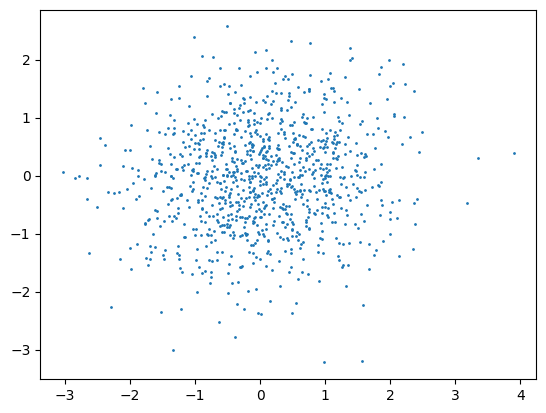

In [3]:
# X~N(0,1) and Y=X
n_batches = 5000
n_samples = 1000
rho = 0.1
eps = np.random.normal(0,1,size=(n_batches, n_samples))
X_alt = np.random.normal(0,1,size=(n_batches, n_samples))
Y_alt = (rho)*X_alt + (1-rho)*eps
X_null = np.random.normal(0,1,size=(n_batches, n_samples))
Y_null = np.random.normal(0,1,size=(n_batches, n_samples))


# plot X vs Y
plt.scatter(X_alt[0], Y_alt[0], s=1)
# plt.savefig(f"plots/rpe/X_vs_Y.pdf", format="pdf", bbox_inches="tight")


Text(0.08936614368817902, 4.675671327533233, '$\\mathcal{H}_1$')

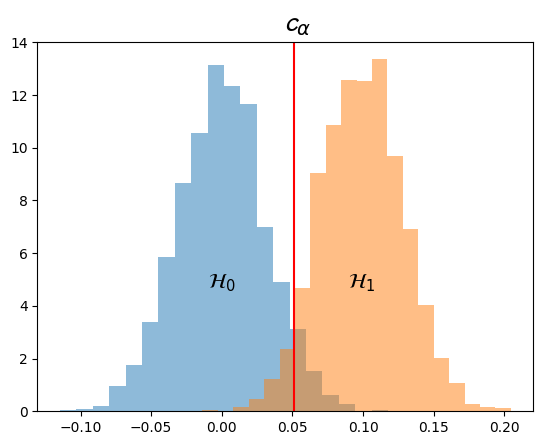

In [4]:
tau_alt = cov(X_alt, Y_alt)
tau_null = cov(X_null, Y_null)
q,i = quantile(tau_null, alpha=0.95)
tau_null.sort()
tau_alt.sort()

# filled
n_null, x_null, _ = plt.hist(tau_null, bins=20, alpha=0.5, histtype='bar', density=True) # weights=np.ones(len(tau_null)) / len(tau_null)
n_alt, x_alt, _ = plt.hist(tau_alt, bins=20, alpha=0.5, histtype='bar', density=True)
plt.axvline(q, color='red')
bottom, top = plt.ylim()
plt.text(q-0.007, top+0.4, s='$\\mathcal{c}_\\alpha$', size=20)
plt.text(tau_null.mean()-0.01, top/3, s='$\\mathcal{H}_0$', size=15)
plt.text(tau_alt.mean()-0.01, top/3, s='$\\mathcal{H}_1$', size=15)

# plt.savefig(f"plots/rpe/H0_H1.pdf", format="pdf", bbox_inches="tight")

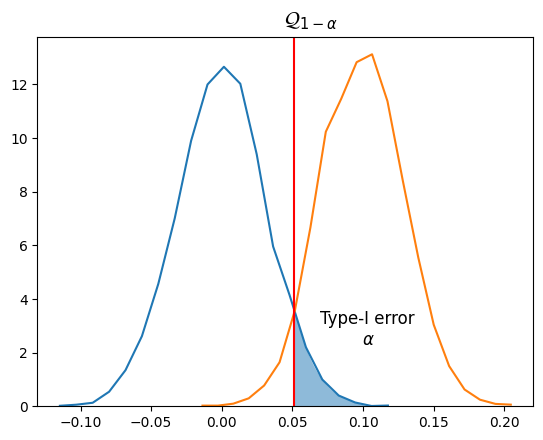

In [6]:
# plot type-1 error
density_null = stats.gaussian_kde(tau_null)
density_alt = stats.gaussian_kde(tau_alt)

plt.plot(x_null, density_null(x_null))
plt.plot(x_alt, density_alt(x_alt))
x_type1 = np.linspace(q, x_null[-1])
plt.fill_between(x_type1, density_null(x_type1), alpha=0.5)

plt.axvline(q, color='red')
bottom, top = plt.ylim()
plt.text(q-0.007, top+0.4, s='$\\mathcal{Q}_{1-\\alpha}$', size=15)
plt.text(tau_alt.mean()-0.03, top/6, s='Type-I error\n\t$\\alpha$', size=12)

plt.ylim(bottom=0)
# plt.savefig(f"plots/rpe/H0_H1_type1.pdf", format="pdf", bbox_inches="tight")

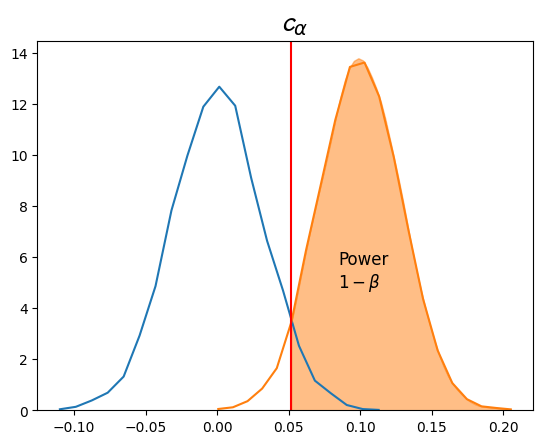

In [58]:
# plot power
density_null = stats.gaussian_kde(tau_null)
density_alt = stats.gaussian_kde(tau_alt)

plt.plot(x_null, density_null(x_null))
plt.plot(x_alt, density_alt(x_alt))
x_power = np.linspace(q, x_alt[-1])
plt.fill_between(x_power, density_alt(x_power), alpha=0.5, color='#ff7f0e')

plt.axvline(q, color='red')
bottom, top = plt.ylim()
plt.text(q-0.007, top+0.4, s='$\\mathcal{c}_\\alpha$', size=20)
plt.text(tau_alt.mean()-0.015, top/3, s='Power\n$1-\\beta$', size=12)

plt.ylim(bottom=0)
# plt.savefig(f"plots/rpe/H0_H1_power.pdf", format="pdf", bbox_inches="tight")

# HSIC Motivation
We consider the "banana" distribution $Y = X^2 + \epsilon$

In [30]:
# X~N(0,1) and Y=X
n_batches = 5000
n_samples = 2000
rho = 0.1
eps = np.random.normal(0,1,size=(n_batches, n_samples))
X_alt = np.random.normal(0,1,size=(n_batches, n_samples))
Y_alt = X_alt**2 + eps
X_null = np.random.normal(0,1,size=(n_batches, n_samples))
Y_null = np.random.normal(0,1,size=(n_batches, n_samples))**2

Text(-0.9, 11.108403381210975, 'Cov(X,Y)=0')

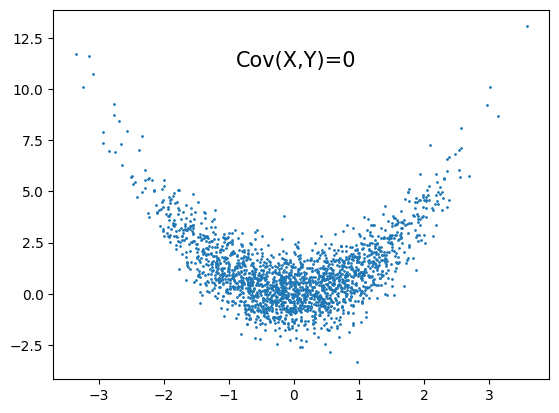

In [31]:
# plot X vs Y
# plt.scatter(X_null[0], Y_null[0], s=1)
plt.scatter(X_alt[0], Y_alt[0], s=1)

bottom, top = plt.ylim()
plt.text(-0.9, 0.8*top, s='Cov(X,Y)=0', size=15)
# plt.savefig(f"plots/rpe/banana.pdf", format="pdf", bbox_inches="tight")

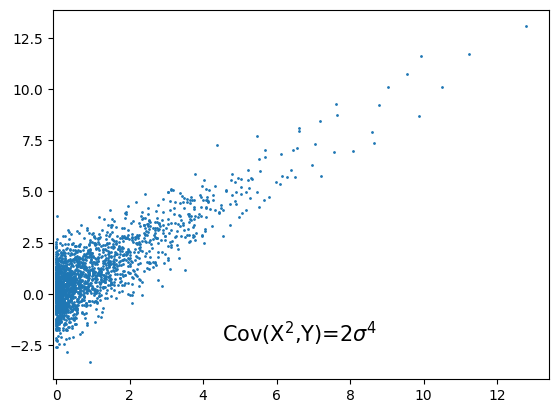

In [35]:
# plot X^2 vs Y
plt.scatter(X_alt[0]**2, Y_alt[0], s=1)
plt.xlim(left=-0.08)

bottom, top = plt.ylim()
plt.text(4.5, 0.1*(top-bottom) + bottom, s='Cov($\\text{X}^2$,Y)=2$\\sigma^4$', size=15)
# plt.savefig(f"plots/rpe/banana_squared.pdf", format="pdf", bbox_inches="tight")

In [13]:
cov(X_alt, Y_alt).mean()

-0.0006891109129902469